<a href="https://colab.research.google.com/github/hellohi900/Concept_and_technology_of_AI/blob/main/2510329_Risab_rai_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Salary_Dataset_DataScienceLovers.csv")
print("Data Loaded. Shape:", df.shape)
df.head()

Data Loaded. Shape: (22770, 8)


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [3]:
# Check for missing values
df.dropna(inplace=True)

# We drop 'Company Name' and 'Job Title' because they have too many unique values
# 'Job Roles' already contains the necessary job information.
cols_to_drop = ['Company Name', 'Job Title']
df_clean = df.drop(columns=cols_to_drop)

print("Columns after cleaning:", df_clean.columns.tolist())

Columns after cleaning: ['Rating', 'Salary', 'Salaries Reported', 'Location', 'Employment Status', 'Job Roles']


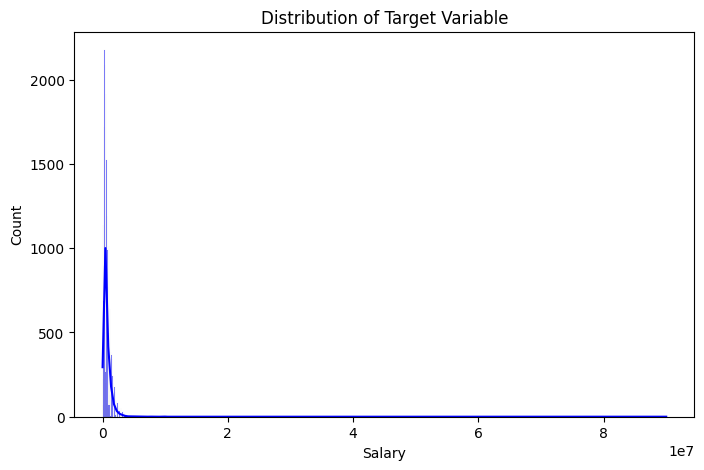

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'], kde=True, color='blue')
plt.title('Distribution of Target Variable')
plt.show()

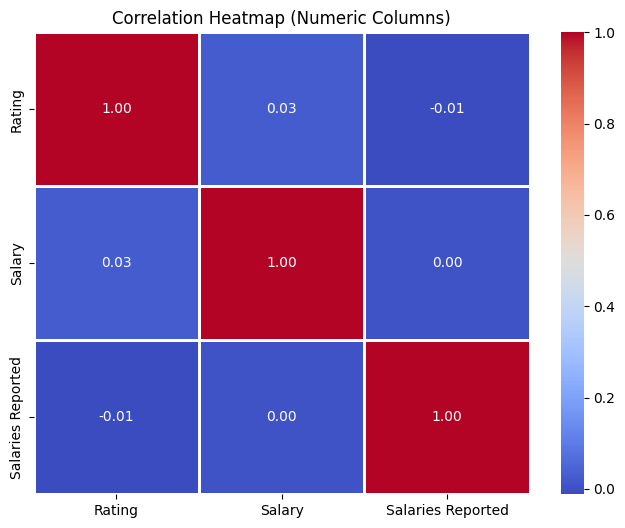

In [5]:
plt.figure(figsize=(8, 6))
numeric_corr = df[['Rating', 'Salary', 'Salaries Reported']].corr()
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap (Numeric Columns)')
plt.show()

In [6]:
# Convert categorical text into numbers (One-Hot Encoding)
X = df_clean.drop("Salary", axis=1)
y = df_clean["Salary"]

X = pd.get_dummies(X, drop_first=True)

# Split into Training (70%) and Testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training features: {X_train.shape[1]}")

Training features: 24


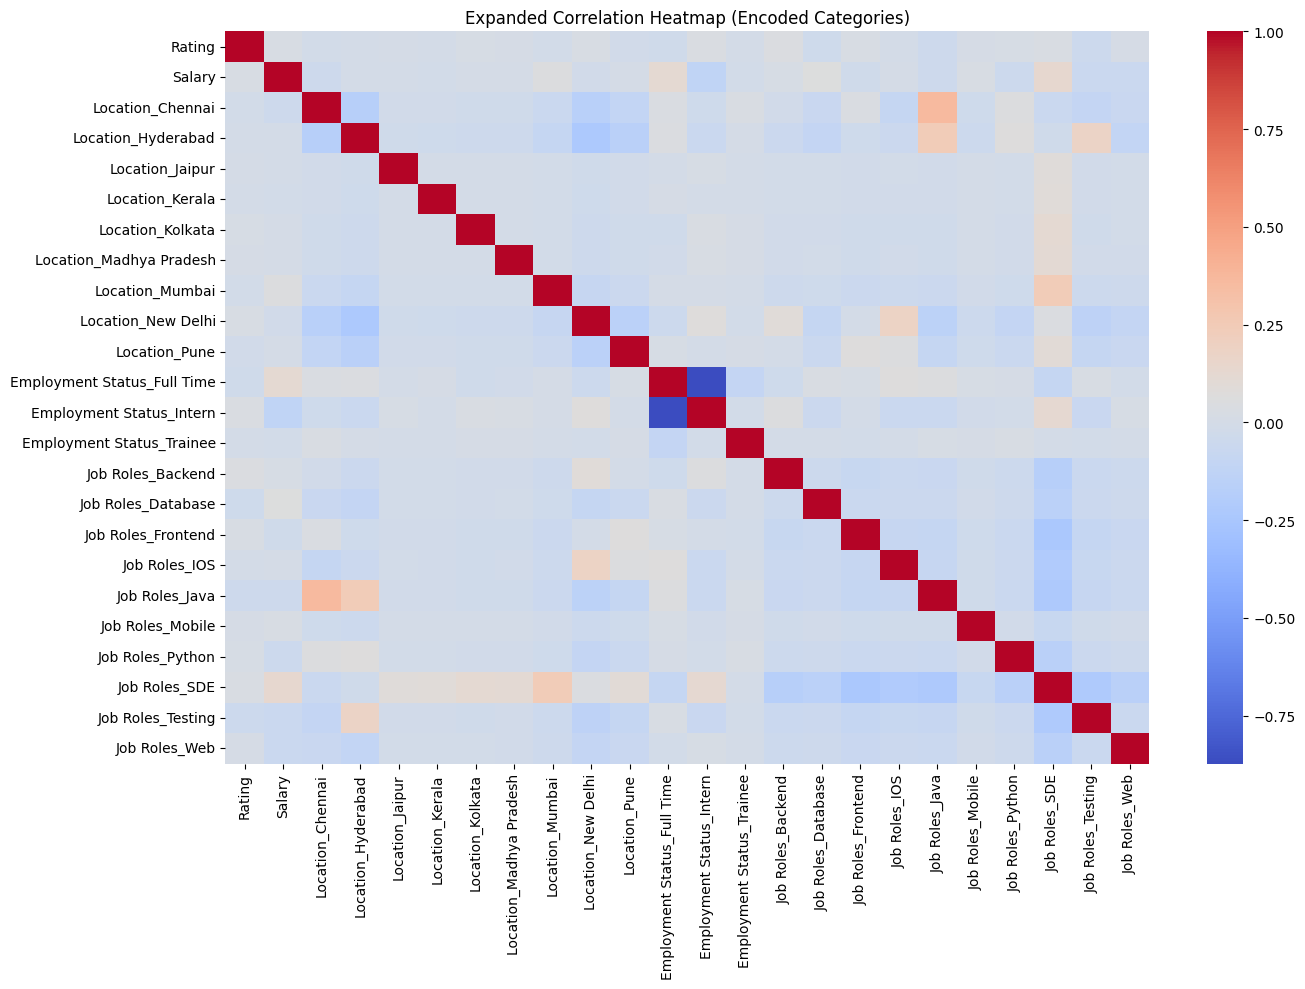

In [7]:
categorical_cols = ['Location', 'Employment Status', 'Job Roles']
df_encoded = pd.get_dummies(df[categorical_cols + ['Rating', 'Salary']], drop_first=True)

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Expanded Correlation Heatmap (Encoded Categories)')
plt.tight_layout()
plt.show()

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


In [13]:
from sklearn.linear_model import LinearRegression
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print(f"KNN R2: {r2_score(y_test, y_pred_knn):.4f}")

Linear Regression R2: 0.1014
KNN R2: -0.0607


In [19]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

In [20]:
mlp = MLPRegressor(hidden_layer_sizes=(64,32),
                   activation='relu',
                   solver='adam',
                   max_iter=2000,
                   random_state=42)

mlp.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = mlp.predict(X_test_scaled)

# Convert back to original salary scale
y_pred_mlp = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()


In [21]:
print("MLP RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlp)))
print("MLP R2:", r2_score(y_test, y_pred_mlp))

MLP RMSE: 605114.415566197
MLP R2: 0.0944936826063606


In [15]:
# Define parameters to test
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

# Randomized Search is much faster than Grid Search
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, # Number of combinations to try
    cv=3,      # 3-fold cross validation
    n_jobs=-1, # Use all CPU cores
    verbose=1,
    random_state=42
)

print("Starting Fast Tuning...")
rf_random.fit(X_train_scaled, y_train)

best_model = rf_random.best_estimator_
y_pred_rf = best_model.predict(X_test_scaled)

print(f"Best Parameters: {rf_random.best_params_}")
print(f"Tuned Random Forest R2: {r2_score(y_test, y_pred_rf):.4f}")

Starting Fast Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
Tuned Random Forest R2: 0.0782


In [16]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import RandomizedSearchCV

# --- Task 5: Feature Selection (Filter Method) ---
# We use SelectKBest to choose the top 10 most influential features.
# This reduces noise and prevents overfitting in both KNN and RF models.
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
print(f"Selected Top 10 Features: {X.columns[selector.get_support()].tolist()}")

# --- Task 4: Hyperparameter Tuning for BOTH models ---

# 1. Tuning Random Forest (Model A)
param_rf = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_rf,
                               n_iter=5, cv=3, n_jobs=-1, verbose=1)
rf_search.fit(X_train_selected, y_train)

# 2. Tuning KNN (Model B)
param_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_search = RandomizedSearchCV(KNeighborsRegressor(), param_knn,
                                n_iter=5, cv=3, n_jobs=-1, verbose=1)
knn_search.fit(X_train_selected, y_train)

print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best KNN Params: {knn_search.best_params_}")

Selected Top 10 Features: ['Location_Chennai', 'Location_Mumbai', 'Employment Status_Full Time', 'Employment Status_Intern', 'Job Roles_Database', 'Job Roles_Java', 'Job Roles_Python', 'Job Roles_SDE', 'Job Roles_Testing', 'Job Roles_Web']
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best RF Params: {'n_estimators': 100, 'max_depth': 10}
Best KNN Params: {'weights': 'distance', 'n_neighbors': 5}


In [17]:
from sklearn.model_selection import cross_val_score

# Task 6: Final Model Comparison Table
models_data = [
    ["Random Forest (Tuned)", 10, np.sqrt(mean_squared_error(y_test, rf_search.predict(X_test_selected))),
     r2_score(y_test, rf_search.predict(X_test_selected)), rf_search.best_score_],
    ["KNN (Tuned)", 10, np.sqrt(mean_squared_error(y_test, knn_search.predict(X_test_selected))),
     r2_score(y_test, knn_search.predict(X_test_selected)), knn_search.best_score_],
    ["MLP Neural Network", 24, np.sqrt(mean_squared_error(y_test, y_pred_mlp)),
     r2_score(y_test, y_pred_mlp), "N/A"]
]

comparison_df = pd.DataFrame(models_data, columns=["Model", "Features", "RMSE", "R2", "CV Score"])
print(comparison_df)

                   Model  Features           RMSE        R2  CV Score
0  Random Forest (Tuned)        10  607506.227718  0.087321  0.063343
1            KNN (Tuned)        10  622362.948502  0.042136  0.042427
2     MLP Neural Network        24  599972.576773  0.109817       N/A


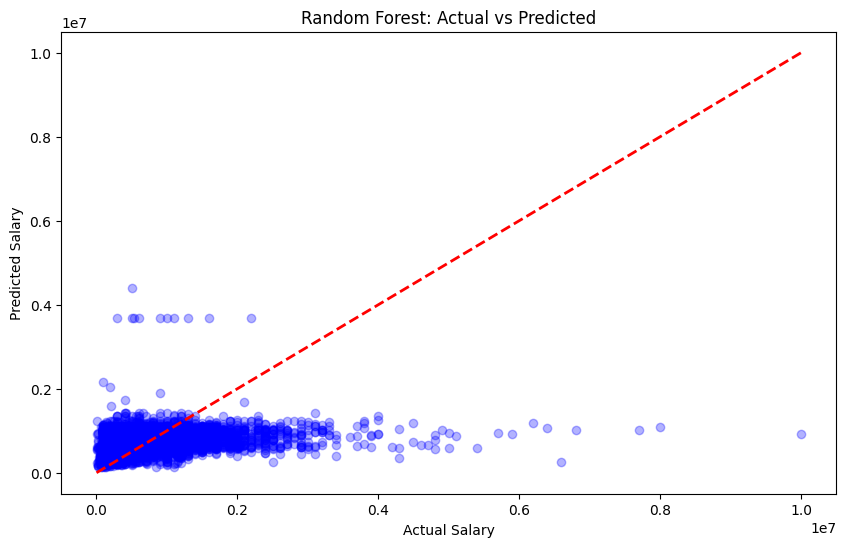

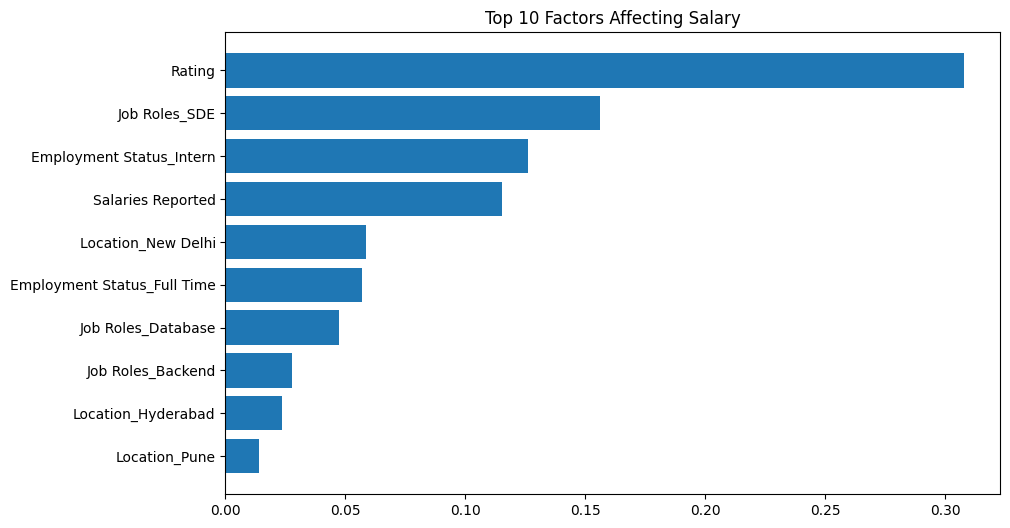

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

# Feature Importance
importances = best_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.title("Top 10 Factors Affecting Salary")
plt.show()